# Rare-event sampling: asymptotics, twisting, tempering, and mixtures

A rare-event estimator can look numerically calm while having catastrophic relative
variance. This tutorial keeps probabilities and second moments in the log domain,
compares crude sampling with tempered and shifted proposals, and shows why a single
dominant-point twist fails for events with multiple minimizers.

**Output semantics.** Every Monte Carlo estimate below is weighted. The Gaussian test
problems have exact probability and exact second-moment oracles, so observed error can
be compared with the true relative standard error rather than judged from event counts
alone.

In [1]:
import importlib.metadata
import os

import matplotlib.pyplot as plt
import numpy as np

from sampler_lab.rare_event_experiments import run_rare_event_experiment
from sampler_lab.rare_events import (
    GaussianHalfspaceRareEvent,
    GaussianTwoSidedRareEvent,
    LaplacePoint,
    gaussian_linear_event_log_asymptotic,
    laplace_integral,
    standard_normal_log_upper_tail,
    standard_normal_upper_tail,
)

QUICK_MODE = os.environ.get("SAMPLER_LAB_NOTEBOOK_MODE") == "quick"
SEED = 2022
FIGURE_COUNT = 0


def finish_figure(fig):
    global FIGURE_COUNT
    fig.tight_layout()
    plt.show()
    plt.close(fig)
    FIGURE_COUNT += 1


print("sampler-lab", importlib.metadata.version("sampler-lab"))
print("execution mode:", "quick" if QUICK_MODE else "publication")
print("master seed:", SEED)

sampler-lab 0.12.0
execution mode: publication
master seed: 2022


## 1. Tail probabilities belong in the log domain

For large $z$, $1-\Phi(z)$ underflows long before its logarithm becomes numerically
uninformative. Stable tail routines let likelihood ratios, asymptotics, and relative
variance calculations survive far into the rare-event regime.

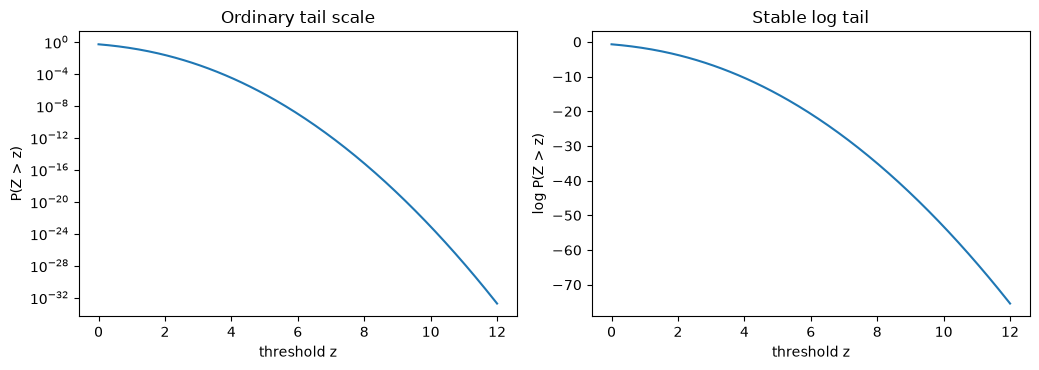

P(Z > 12): 1.776482112077679e-33
log P(Z > 40): -804.6084420137538


In [2]:
thresholds = np.linspace(0.0, 12.0, 240)
tails = np.array([standard_normal_upper_tail(value) for value in thresholds])
log_tails = np.array([standard_normal_log_upper_tail(value) for value in thresholds])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].semilogy(thresholds, np.maximum(tails, np.finfo(float).tiny))
axes[0].set_xlabel("threshold z")
axes[0].set_ylabel("P(Z > z)")
axes[0].set_title("Ordinary tail scale")
axes[1].plot(thresholds, log_tails)
axes[1].set_xlabel("threshold z")
axes[1].set_ylabel("log P(Z > z)")
axes[1].set_title("Stable log tail")
finish_figure(fig)

print("P(Z > 12):", standard_normal_upper_tail(12.0))
print("log P(Z > 40):", standard_normal_log_upper_tail(40.0))
assert np.all(np.diff(log_tails) < 0.0)
assert np.isfinite(standard_normal_log_upper_tail(40.0))

## 2. Laplace approximations must sum all minimizers

For isolated interior minimizers $x_i$, the leading approximation is a sum of local
Gaussian contributions. Two equal minimizers double the prefactor: keeping only one
gets the exponential rate right while missing a persistent factor of two.

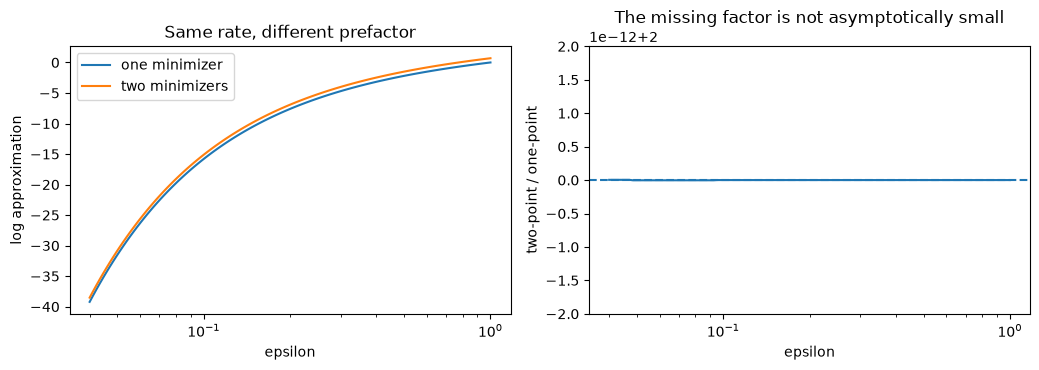

In [3]:
epsilons = np.geomspace(0.04, 1.0, 120)
one_point = [LaplacePoint(1.5, np.array([[2.0, 0.2], [0.2, 1.0]]))]
two_points = [
    LaplacePoint(1.5, np.array([[2.0, 0.2], [0.2, 1.0]])),
    LaplacePoint(1.5, np.array([[2.0, 0.2], [0.2, 1.0]])),
]
one_logs = np.array([laplace_integral(one_point, eps).log_value for eps in epsilons])
two_logs = np.array([laplace_integral(two_points, eps).log_value for eps in epsilons])

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
axes[0].plot(epsilons, one_logs, label="one minimizer")
axes[0].plot(epsilons, two_logs, label="two minimizers")
axes[0].set_xscale("log")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("log approximation")
axes[0].legend()
axes[0].set_title("Same rate, different prefactor")
axes[1].plot(epsilons, np.exp(two_logs - one_logs))
axes[1].axhline(2.0, linestyle="--")
axes[1].set_xscale("log")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("two-point / one-point")
axes[1].set_title("The missing factor is not asymptotically small")
finish_figure(fig)

assert np.allclose(two_logs - one_logs, np.log(2.0), atol=1e-12)

## 3. Boundary-Laplace asymptotics for Gaussian halfspaces

For $X_\varepsilon\sim N(0,\varepsilon\Sigma)$ and a linear threshold, the exact
probability is available. The dominant exponential rate is

$$
I_\star = \frac{b^2}{2a^\mathsf{T}\Sigma a}.
$$

A two-sided event has two equal dominating points and therefore an additional factor of
two in the leading prefactor.

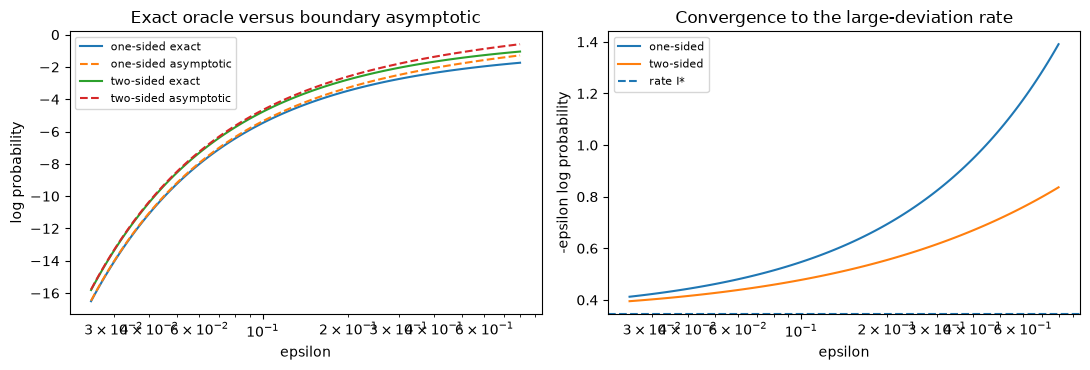

In [4]:
direction = np.array([1.0, 0.5])
direction /= np.linalg.norm(direction)
covariance = np.array([[1.0, 0.35], [0.35, 1.8]])
one_sided = GaussianHalfspaceRareEvent(direction, 1.0, covariance)
two_sided = GaussianTwoSidedRareEvent(direction, 1.0, covariance)
noise_levels = np.geomspace(0.025, 0.8, 120)

exact_one = np.array([one_sided.exact_log_probability(eps) for eps in noise_levels])
asym_one = np.array([gaussian_linear_event_log_asymptotic(one_sided, eps) for eps in noise_levels])
exact_two = np.array([two_sided.exact_log_probability(eps) for eps in noise_levels])
asym_two = np.array([gaussian_linear_event_log_asymptotic(two_sided, eps) for eps in noise_levels])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(noise_levels, exact_one, label="one-sided exact")
axes[0].plot(noise_levels, asym_one, linestyle="--", label="one-sided asymptotic")
axes[0].plot(noise_levels, exact_two, label="two-sided exact")
axes[0].plot(noise_levels, asym_two, linestyle="--", label="two-sided asymptotic")
axes[0].set_xscale("log")
axes[0].set_xlabel("epsilon")
axes[0].set_ylabel("log probability")
axes[0].legend(fontsize=8)
axes[0].set_title("Exact oracle versus boundary asymptotic")
axes[1].plot(noise_levels, -noise_levels * exact_one, label="one-sided")
axes[1].plot(noise_levels, -noise_levels * exact_two, label="two-sided")
axes[1].axhline(one_sided.rate, linestyle="--", label="rate I*")
axes[1].set_xscale("log")
axes[1].set_xlabel("epsilon")
axes[1].set_ylabel("-epsilon log probability")
axes[1].set_title("Convergence to the large-deviation rate")
axes[1].legend(fontsize=8)
finish_figure(fig)

assert abs((-noise_levels[0] * exact_one[0]) - one_sided.rate) < 0.15
assert np.allclose(exact_two - exact_one, np.log(2.0), atol=1e-10)

## 4. Crude sampling, tempering, and dominant-point twisting

The experiment below uses exact second moments to report the true relative standard
error. For a one-sided event, shifting to the dominant point is asymptotically
efficient. For a symmetric two-sided event, a single twist over-samples only one
minimizer; a symmetric mixture must cover both.

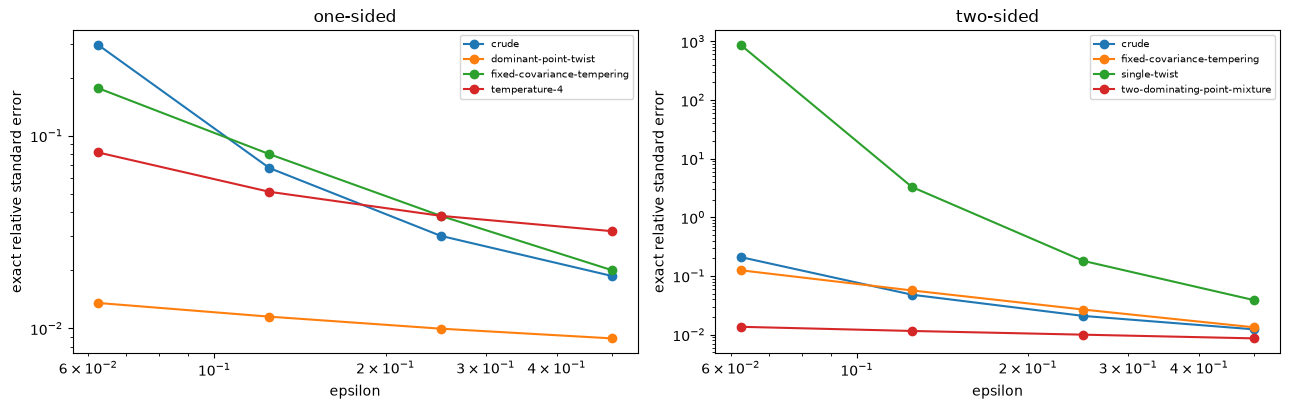

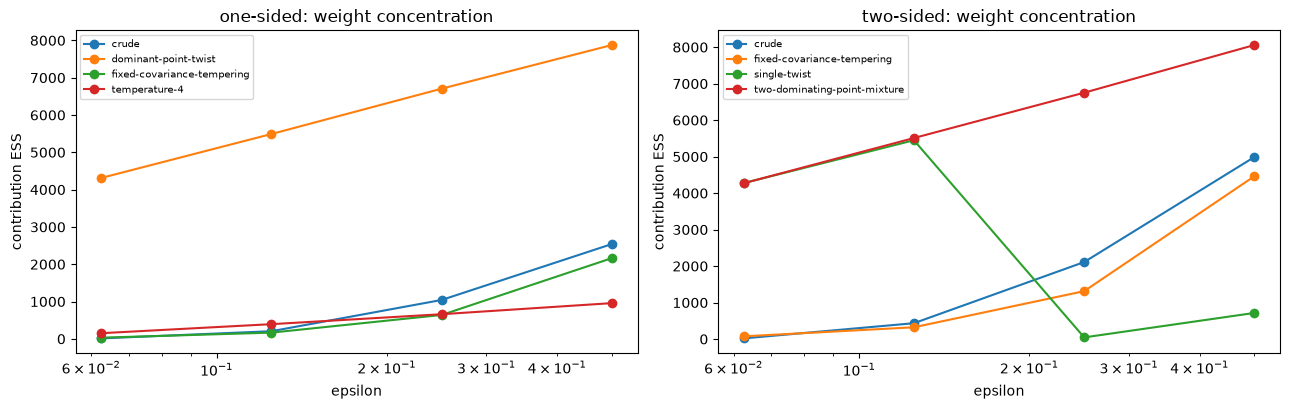

one-sided  crude                          eps= 0.5000 estimate=     0.127 truth=     0.125 exact RSE=   0.0187 events= 2542
one-sided  temperature-4                  eps= 0.5000 estimate=     0.126 truth=     0.125 exact RSE=   0.0319 events= 5667
one-sided  fixed-covariance-tempering     eps= 0.5000 estimate=     0.121 truth=     0.125 exact RSE=     0.02 events= 4166
one-sided  dominant-point-twist           eps= 0.5000 estimate=     0.127 truth=     0.125 exact RSE=  0.00887 events=10118
one-sided  crude                          eps= 0.2500 estimate=    0.0522 truth=     0.052 exact RSE=   0.0302 events= 1043
one-sided  temperature-4                  eps= 0.2500 estimate=    0.0539 truth=     0.052 exact RSE=   0.0384 events= 4105
one-sided  fixed-covariance-tempering     eps= 0.2500 estimate=    0.0543 truth=     0.052 exact RSE=   0.0384 events= 4163
one-sided  dominant-point-twist           eps= 0.2500 estimate=    0.0519 truth=     0.052 exact RSE=  0.00996 events=10069
one-side

In [5]:
experiment_epsilons = (0.5, 0.3) if QUICK_MODE else (0.5, 0.25, 0.125, 0.0625)
rows = run_rare_event_experiment(
    epsilons=experiment_epsilons,
    n_samples=4_000 if QUICK_MODE else 20_000,
    dimension=4,
    seed=SEED,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for axis, problem_name in zip(axes, ("one-sided", "two-sided"), strict=True):
    methods = sorted({row.method for row in rows if row.problem == problem_name})
    for method in methods:
        selected = sorted(
            (row for row in rows if row.problem == problem_name and row.method == method),
            key=lambda row: row.epsilon,
        )
        axis.plot(
            [row.epsilon for row in selected],
            [row.exact_relative_standard_error for row in selected],
            marker="o",
            label=method,
        )
    axis.set_xscale("log")
    axis.set_yscale("log")
    axis.set_xlabel("epsilon")
    axis.set_ylabel("exact relative standard error")
    axis.set_title(problem_name)
    axis.legend(fontsize=7)
finish_figure(fig)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for axis, problem_name in zip(axes, ("one-sided", "two-sided"), strict=True):
    methods = sorted({row.method for row in rows if row.problem == problem_name})
    for method in methods:
        selected = sorted(
            (row for row in rows if row.problem == problem_name and row.method == method),
            key=lambda row: row.epsilon,
        )
        axis.plot(
            [row.epsilon for row in selected],
            [row.contribution_ess for row in selected],
            marker="o",
            label=method,
        )
    axis.set_xscale("log")
    axis.set_xlabel("epsilon")
    axis.set_ylabel("contribution ESS")
    axis.set_title(f"{problem_name}: weight concentration")
    axis.legend(fontsize=7)
finish_figure(fig)

for row in rows:
    print(
        f"{row.problem:10s} {row.method:30s} eps={row.epsilon:7.4f} "
        f"estimate={row.estimate:10.3g} truth={row.truth:10.3g} "
        f"exact RSE={row.exact_relative_standard_error:9.3g} "
        f"events={row.event_count:5d}"
    )

smallest = min(experiment_epsilons)
one_small = {
    row.method: row for row in rows if row.problem == "one-sided" and row.epsilon == smallest
}
two_small = {
    row.method: row for row in rows if row.problem == "two-sided" and row.epsilon == smallest
}
assert (
    one_small["dominant-point-twist"].exact_relative_standard_error
    < one_small["crude"].exact_relative_standard_error
)
assert (
    two_small["two-dominating-point-mixture"].exact_relative_standard_error
    < two_small["single-twist"].exact_relative_standard_error
)

## Takeaways

- Rare probabilities and second moments should be computed in the log domain.
- Exponential-rate agreement does not guarantee a correct prefactor.
- Event counts are not a variance diagnostic; contribution ESS and exact relative error
  expose weight collapse.
- Dominant-point twisting is geometry aware. Multiple minimizers generally require a
  proposal mixture rather than a heroic single shift.
- Tempering can help, but the small-noise scaling of the proposal matters.

In [6]:
assert FIGURE_COUNT >= 5
print("figures rendered:", FIGURE_COUNT)

figures rendered: 5
